# Bildklassifikation für Qualitätskontrolle im Agrarbereich
## MobileNetV2 mit Transfer Learning, Fine-Tuning & Data Augmentation

**Verbesserungen gegenüber dem ursprünglichen Notebook:**
- ✅ Data Augmentation (Flip, Rotation, Brightness, Zoom)
- ✅ Fine-Tuning der oberen MobileNetV2-Schichten
- ✅ Besseres EarlyStopping (val_loss überwachen)
- ✅ Learning Rate Scheduler
- ✅ Trainingsvisualisierung

## 1. Imports & Konfiguration

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print("TensorFlow Version:", tf.__version__)
print("GPU verfügbar:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU verfügbar: []


In [16]:
# ── Konfiguration ──────────────────────────────────────────────────────────────
DATA_DIR   = Path(r"c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data_sing")
IMG_SIZE   = (224, 224)   # MobileNetV2 erwartet 224x224
BATCH_SIZE = 32
SEED       = 42

# Trainingsparameter
EPOCHS_TRANSFER  = 5   # Phase 1: nur Dense-Head trainieren
EPOCHS_FINETUNE  = 3   # Phase 2: obere Schichten fine-tunen
LR_TRANSFER      = 1e-3
LR_FINETUNE      = 1e-5  # sehr klein für Fine-Tuning!
FINETUNE_FROM    = 100   # ab diesem Layer auftauen (von ~154 gesamt)

MODEL_PATH       = "bestModel_mobilenet.keras"

## 2. Dataset laden & aufteilen (70/15/15)

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.3,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Temp-Split in Val und Test aufteilen
temp_batches = temp_ds.cardinality().numpy()
val_batches  = temp_batches // 2
val_ds   = temp_ds.take(val_batches)
test_ds  = temp_ds.skip(val_batches)

print("Klassen:",             class_names)
print("Training Batches:",    train_ds.cardinality().numpy())
print("Validation Batches:",  val_ds.cardinality().numpy())
print("Test Batches:",        test_ds.cardinality().numpy())

Found 4817 files belonging to 2 classes.
Using 3372 files for training.
Found 4817 files belonging to 2 classes.
Using 1445 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 106
Validation Batches: 23
Test Batches: 23


## 3. Data Augmentation

Besonders wichtig für Agrardaten: Bilder entstehen unter wechselnden
Lichtverhältnissen, Kamerawinkeln und Abständen.

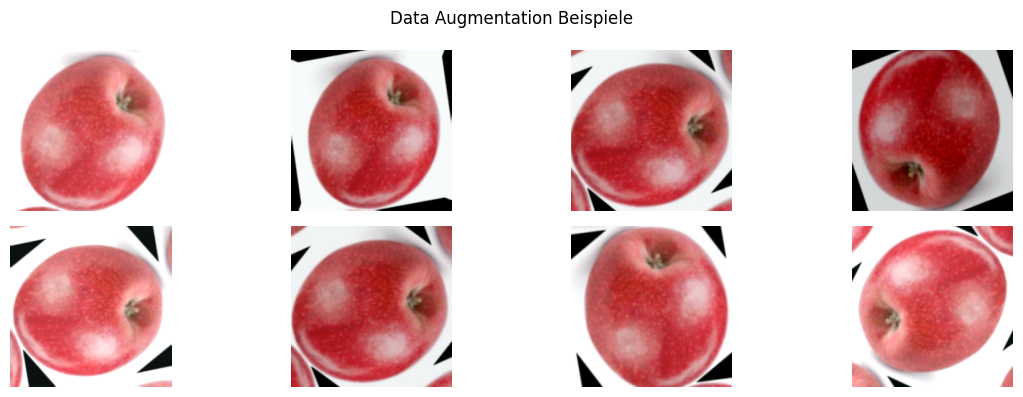

In [18]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.1),
], name="augmentation")

# Augmentation-Vorschau
sample_images, _ = next(iter(train_ds))
plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = data_augmentation(tf.expand_dims(sample_images[0], 0), training=True)
    plt.imshow(aug_img[0].numpy().astype("uint8"))
    plt.axis("off")
plt.suptitle("Data Augmentation Beispiele")
plt.tight_layout()
plt.show()

## 4. Performance-Optimierung des Datenpipeline

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

# Nur Training erhält Augmentation — Val/Test niemals!
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_ds  = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 5. Modell aufbauen

**Phase 1:** MobileNetV2 eingefroren, nur Dense-Head trainieren  
**Phase 2:** Obere Schichten auftauen und mit sehr kleiner LR fine-tunen

In [ ]:
def build_model(num_classes, finetune=False, finetune_from=100):
    """Baut das MobileNetV2-Modell.
    finetune=False  → alle Base-Schichten eingefroren
    finetune=True   → Schichten ab finetune_from auftauen
    """
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    if finetune:
        base_model.trainable = True
        for layer in base_model.layers[:finetune_from]:
            layer.trainable = False
        print(f"Fine-Tuning: {sum(l.trainable for l in base_model.layers)} "
              f"von {len(base_model.layers)} Schichten trainierbar")
    else:
        base_model.trainable = False
        print("Transfer Learning: Base Model eingefroren")

    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(scale=1./127.5, offset=-1.0, name="mobilenet_preprocess"),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ], name="MobileNetV2_Agrarkontrolle")

    return model, base_model

model, base_model = build_model(num_classes)
model.summary()

Transfer Learning: Base Model eingefroren


Model: "MobileNetV2_Agrarkontrolle"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenet_preprocess (Lambda)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,591,554 (9.89 MB)

 Trainable params: 331,010 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 6. Phase 1 – Transfer Learning (Base eingefroren)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_TRANSFER),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("=== Phase 1: Transfer Learning ===")
history_transfer = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER,
    callbacks=callbacks_phase1
)

=== Phase 1: Transfer Learning ===
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.8928 - loss: 0.2897
Epoch 1: val_loss improved from None to 0.06646, saving model to bestModel_mobilenet.keras

Epoch 1: finished saving model to bestModel_mobilenet.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 107s 832ms/step - accuracy: 0.9434 - loss: 0.1647 - val_accuracy: 0.9823 - val_loss: 0.0665 - learning_rate: 0.0010
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.9654 - loss: 0.1048
Epoch 2: val_loss improved from 0.06646 to 0.05489, saving model to bestModel_mobilenet.keras

Epoch 2: finished saving model to bestModel_mobilenet.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 136s 776ms/step - accuracy: 0.9677 - loss: 0.0907 - val_accuracy: 0.9851 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9744 - loss: 0.0653
Epoch 3: val_loss improved from 0.05489 to 0.04261, saving model to bestModel_mobilenet.keras

Epoch 3: fin

## 7. Phase 2 – Fine-Tuning (obere Schichten auftauen)

In [22]:
# Obere Schichten des Base Models auftauen
base_model.trainable = True
for layer in base_model.layers[:FINETUNE_FROM]:
    layer.trainable = False

trainable_count = sum(l.trainable for l in base_model.layers)
print(f"Fine-Tuning: {trainable_count} von {len(base_model.layers)} Base-Schichten trainierbar")

# Sehr kleine Learning Rate für Fine-Tuning!
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("=== Phase 2: Fine-Tuning ===")
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    callbacks=callbacks_phase2
)

Fine-Tuning: 54 von 154 Base-Schichten trainierbar
=== Phase 2: Fine-Tuning ===
Epoch 1/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9224 - loss: 0.2443
Epoch 1: val_loss improved from None to 0.12472, saving model to bestModel_mobilenet.keras

Epoch 1: finished saving model to bestModel_mobilenet.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9339 - loss: 0.2085 - val_accuracy: 0.9633 - val_loss: 0.1247
Epoch 2/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9586 - loss: 0.1234
Epoch 2: val_loss did not improve from 0.12472
106/106 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9644 - loss: 0.1122 - val_accuracy: 0.9606 - val_loss: 0.1338
Epoch 3/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9686 - loss: 0.0902
Epoch 3: val_loss did not improve from 0.12472
106/106 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9730 - loss: 0.0873 - val_accuracy: 0.9579 - val_loss: 0.1718
Restoring model weights from the end of the best epoch: 1.


## 8. Trainingsverläufe visualisieren

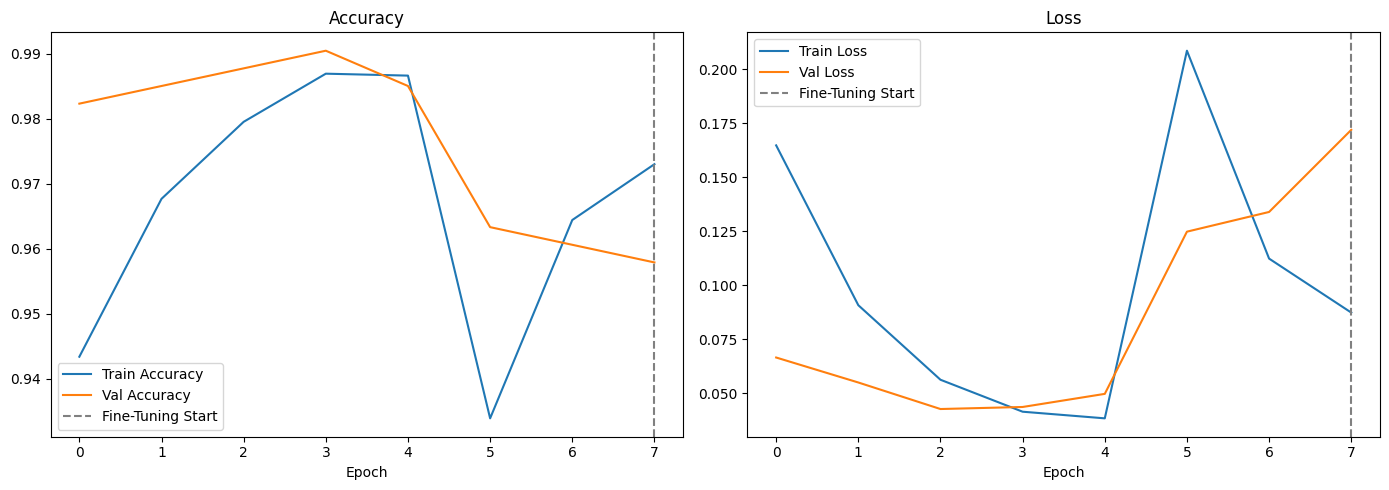

In [23]:
def plot_history(h1, h2=None):
    """Zeigt Accuracy und Loss beider Trainingsphasen."""
    acc  = h1.history["accuracy"]
    val_acc  = h1.history["val_accuracy"]
    loss = h1.history["loss"]
    val_loss = h1.history["val_loss"]

    if h2:
        acc      += h2.history["accuracy"]
        val_acc  += h2.history["val_accuracy"]
        loss     += h2.history["loss"]
        val_loss += h2.history["val_loss"]
        split_at = len(h1.history["accuracy"])
    else:
        split_at = None

    epochs_range = range(len(acc))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, label="Train Accuracy")
    ax1.plot(epochs_range, val_acc, label="Val Accuracy")
    if split_at:
        ax1.axvline(split_at - 1, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax1.set_title("Accuracy"); ax1.legend(); ax1.set_xlabel("Epoch")

    ax2.plot(epochs_range, loss, label="Train Loss")
    ax2.plot(epochs_range, val_loss, label="Val Loss")
    if split_at:
        ax2.axvline(split_at - 1, color="gray", linestyle="--", label="Fine-Tuning Start")
    ax2.set_title("Loss"); ax2.legend(); ax2.set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()

plot_history(history_transfer, history_finetune)

## 9. Evaluation auf dem Test-Set

In [26]:
# Bestes Modell laden
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"preprocess_input": preprocess_input}
)

print("=== Test-Set Evaluation ===")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

=== Test-Set Evaluation ===
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 670ms/step - accuracy: 0.9661 - loss: 0.1015
Test Accuracy: 0.9661
Test Loss:     0.1015


## 10. Confusion Matrix & Classification Report

                precision    recall  f1-score   support

Apple__Healthy       0.93      1.00      0.96       286
 Apple__Rotten       1.00      0.95      0.97       423

      accuracy                           0.97       709
     macro avg       0.96      0.97      0.97       709
  weighted avg       0.97      0.97      0.97       709



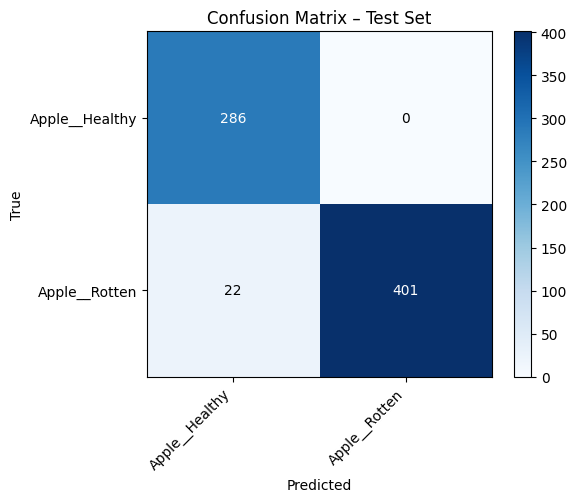

In [27]:
y_true, y_pred = [], []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix visualisieren
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix – Test Set")
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 11. Falsch klassifizierte Bilder analysieren

Falsch klassifiziert: 21 Bilder


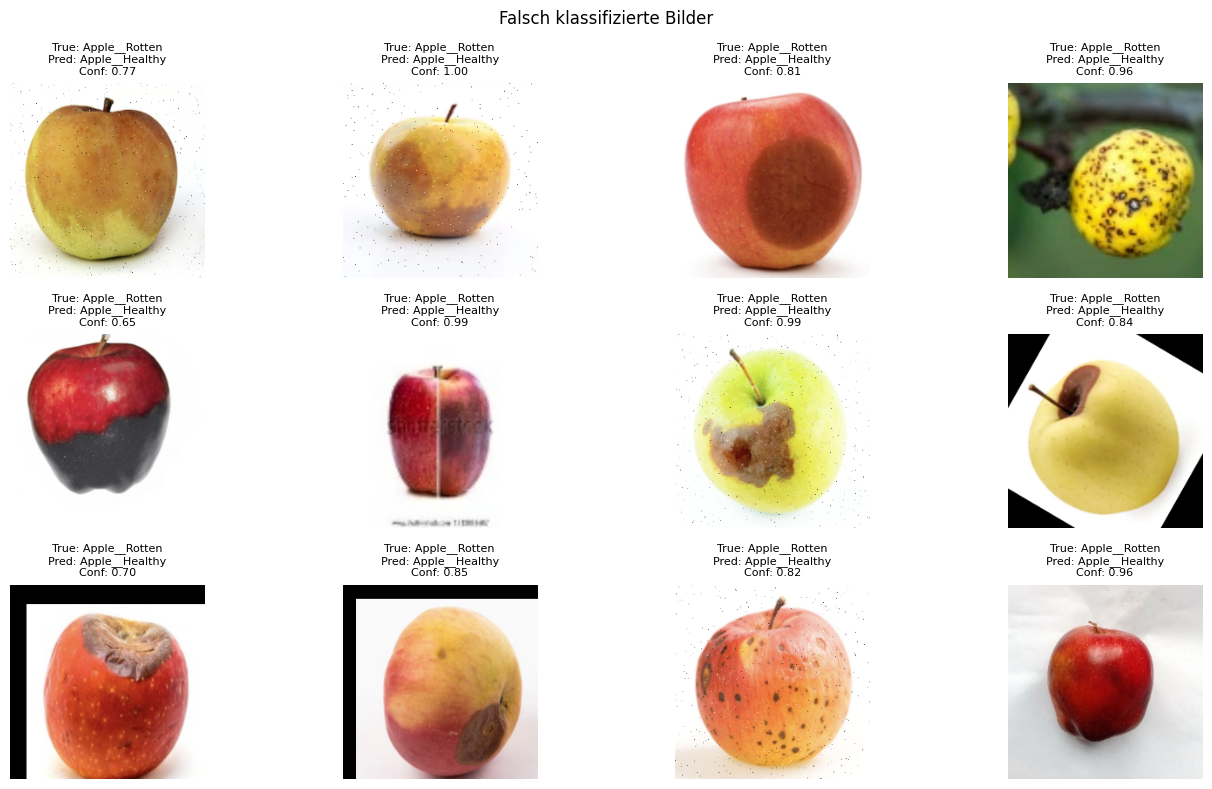

In [28]:
wrong_images, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    preds       = model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1)

    for i in range(len(labels)):
        t = int(labels[i].numpy())
        p = int(pred_labels[i])
        if t != p:
            wrong_images.append(images[i].numpy().astype("uint8"))
            wrong_true.append(t)
            wrong_pred.append(p)
            wrong_conf.append(float(confidences[i]))

print(f"Falsch klassifiziert: {len(wrong_images)} Bilder")

n = min(12, len(wrong_images))
if n > 0:
    plt.figure(figsize=(14, 8))
    for i in range(n):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(wrong_images[i])
        plt.title(
            f"True: {class_names[wrong_true[i]]}\n"
            f"Pred: {class_names[wrong_pred[i]]}\n"
            f"Conf: {wrong_conf[i]:.2f}",
            fontsize=8
        )
        plt.axis("off")
    plt.suptitle("Falsch klassifizierte Bilder", fontsize=12)
    plt.tight_layout()
    plt.savefig("wrong_predictions.png", dpi=150)
    plt.show()
else:
    print("Keine Fehler gefunden – perfekte Klassifikation auf dem Test-Set!")

## 12. Einzelbild-Inferenz (für Produktivsystem)

Diese Funktion kannst du direkt in eine Kamera-Pipeline einbinden.

In [ ]:
def predict_single_image(image_path: str, model, class_names: list):
    """Klassifiziert ein einzelnes Bild und gibt Klasse + Konfidenz zurück."""
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Batch-Dimension

    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = float(np.max(predictions[0]))

    print(f"Klasse:     {predicted_class}")
    print(f"Konfidenz:  {confidence:.2%}")
    print(f"Alle Scores: { {c: f'{p:.2%}' for c, p in zip(class_names, predictions[0])} }")

    return predicted_class, confidence

# Beispielaufruf:
# predicted_class, conf = predict_single_image("pfad/zum/bild.jpg", model, class_names)

---
## Nächste Schritte für dein Projekt

1. **Mehr Klassen hinzufügen** – z.B. `Early_Rot`, `Schimmel`, `Druckstellen`
2. **Schwellenwert für Konfidenz setzen** – Bilder unter ~70% Konfidenz zur manuellen Prüfung flaggen
3. **Modell exportieren** für Edge-Deployment:
   ```python
   # TensorFlow Lite für Raspberry Pi / Jetson Nano
   converter = tf.lite.TFLiteConverter.from_saved_model(MODEL_PATH)
   tflite_model = converter.convert()
   with open('model.tflite', 'wb') as f:
       f.write(tflite_model)
   ```
4. **Weitere Kulturen** – dasselbe Notebook funktioniert für andere Ordner im Dataset